In [110]:
%reset -f
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt

In [111]:
X_no_bias = np.array([[0,0],[1,0],[0,1],[1,1]], float)
T        = np.array([[0],[1],[1],[0]], float)
X = np.hstack([X_no_bias, np.ones((4,1))])

In [112]:
lr       = 0.08            # 조금 키움 (0.07~0.12 범위 실험해도 됨)
epochs   = 60000
patience = 3000
min_delta= 1e-6
ema_alpha= 0.9 

In [113]:
rng = np.random.default_rng(42)

In [117]:
def sigmoid(z): return 1.0/(1.0+np.exp(-z))
def d_sigmoid(y): return y*(1.0-y)
def mse(y,t):     return 0.5*np.mean((t-y)**2)

def xavier_init(in_dim, out_dim, rng):
    # Sigmoid용 Xavier: N(0, sqrt(1/in_dim))
    std = np.sqrt(1.0/in_dim)
    return rng.normal(0.0, std, size=(in_dim, out_dim))

def forward(W1, W2, Xb):
    h  = sigmoid(Xb @ W1)                             # (n,2)
    hb = np.hstack([h, np.ones((h.shape[0],1))])      # (n,3)
    o  = sigmoid(hb @ W2)                             # (n,1)
    return h, hb, o

def train_one_split(train_idx, val_idx):
    # ----- 초기화: Xavier -----
    W1 = np.hstack([
        xavier_init(3, 1, rng),
        xavier_init(3, 1, rng)
    ])                               # (3,2)
    W2 = xavier_init(3, 1, rng)      # (3,1)

    # 이 두 줄이 Xtr, Ttr, Xval, Tval 정의
    Xtr, Ttr = X[train_idx], T[train_idx]
    Xval, Tval = X[val_idx], T[val_idx]

    train_mse, val_mse, val_ema = [], [], []
    best_val = np.inf
    best_W1, best_W2 = W1.copy(), W2.copy()
    wait, stop_epoch = 0, None
    last_ema = None

In [ ]:
for ep in range(epochs):
    # --- SGD: 학습 샘플 섞기 ---
    for i in rng.permutation(len(Xtr)):
        xi, ti = Xtr[i:i+1], Ttr[i:i+1]   # ← 여기서 Xtr/Ttr 사용 가능
        # forward
        h  = sigmoid(xi @ W1)
        hb = np.hstack([h, np.ones((1,1))])
        o  = sigmoid(hb @ W2)
        # backward
        delta_o = (o - ti) * d_sigmoid(o)
        delta_h = (delta_o @ W2[:2].T) * d_sigmoid(h)
        # update
        W2 -= lr * (hb.T @ delta_o)
        W1 -= lr * (xi.T @ delta_h)

    # --- epoch 손실 ---
    _, _, o_tr  = forward(W1, W2, Xtr)
    _, _, o_val = forward(W1, W2, Xval)
    trE, vaE = mse(o_tr, Ttr), mse(o_val, Tval)
    train_mse.append(trE); val_mse.append(vaE)

    # --- EMA 스무딩 ---
    last_ema = vaE if last_ema is None else (ema_alpha*last_ema + (1-ema_alpha)*vaE)
    val_ema.append(last_ema)

    if (best_val - last_ema) > min_delta:
        best_val = last_ema
        best_W1, best_W2 = W1.copy(), W2.copy()
        wait = 0
    else:
        wait += 1
        if wait >= patience:
            stop_epoch = ep + 1

return W1, W2, np.array(train_mse), np.array(val_mse), np.array(val_ema), stop_epoch, best_val

NameError: name 'Xtr' is not defined

In [108]:
train_idx = np.array([0,1,2]);  val_idx = np.array([3])
Xtr, Ttr = X[train_idx], T[train_idx]
Xval, Tval = X[val_idx], T[val_idx]

def forward(W1, W2, Xb):
    h  = sigmoid(Xb @ W1)
    hb = np.hstack([h, np.ones((h.shape[0],1))])
    o  = sigmoid(hb @ W2)
    return h, hb, o

train_mse, val_mse = [], []
best_val = np.inf
best_W1, best_W2 = W1.copy(), W2.copy()
wait = 0
stop_epoch = None

for ep in range(epochs):
    # SGD
    for i in rng.permutation(len(Xtr)):
        xi, ti = Xtr[i:i+1], Ttr[i:i+1]
        h  = sigmoid(xi @ W1)
        hb = np.hstack([h, np.ones((1,1))])
        o  = sigmoid(hb @ W2)
        delta_o = (o - ti) * d_sigmoid(o)
        delta_h = (delta_o @ W2[:2].T) * d_sigmoid(h)
        W2 -= lr * (hb.T @ delta_o)
        W1 -= lr * (xi.T @ delta_h)

    _, _, o_tr  = forward(W1, W2, Xtr)
    _, _, o_val = forward(W1, W2, Xval)
    trE, vaE = mse(o_tr, Ttr), mse(o_val, Tval)
    train_mse.append(trE); val_mse.append(vaE)

    if best_val - vaE > min_delta:
        best_val = vaE; best_W1, best_W2 = W1.copy(), W2.copy()
        wait = 0
    else:
        wait += 1
        if wait >= patience:
            stop_epoch = ep + 1
            break

len(train_mse) = 2001  len(val_mse) = 2001
best val = 0.1582492496504891  stop_epoch = 2001


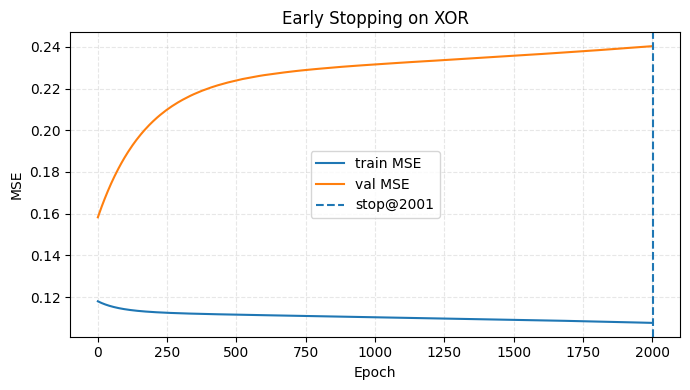

In [109]:
W1, W2 = best_W1, best_W2

print("len(train_mse) =", len(train_mse), " len(val_mse) =", len(val_mse))
print("best val =", best_val, " stop_epoch =", stop_epoch)

plt.figure(figsize=(7,4))
x = np.arange(len(train_mse))
plt.plot(x, train_mse, label="train MSE")
plt.plot(x, val_mse,   label="val MSE")
if stop_epoch is not None:
    plt.axvline(stop_epoch, linestyle="--", label=f"stop@{stop_epoch}")
plt.title("Early Stopping on XOR")
plt.xlabel("Epoch"); plt.ylabel("MSE")
plt.legend(); plt.grid(True, linestyle="--", alpha=0.3)
plt.tight_layout(); plt.show()

파랑 : 학습데이터에서의 평균제곱오차
주황 : 검증데이터에서의 평균제곱오차
점선 : 얼리스타핑이 멈춘시점